In [51]:
import os
from dotenv import load_dotenv
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm

from transformers import GPT2LMHeadModel, GPT2TokenizerFast

from typing import Literal

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

In [52]:
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

KeyboardInterrupt: 

In [ ]:
def get_device():
    if torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"

device = get_device()
print(device)

mps


In [ ]:
dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [ ]:
dataset['train']['text'][:10]

['',
 ' = Valkyria Chronicles III = \n',
 '',
 ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more f

In [ ]:
train_dataset = dataset['train']['text']
train_dataset[1]

' = Valkyria Chronicles III = \n'

In [ ]:
dataset['test']['text'][:10]

['',
 ' = Robert Boulter = \n',
 '',
 ' Robert Boulter is an English film , television and theatre actor . He had a guest @-@ starring role on the television series The Bill in 2000 . This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre . He had a guest role in the television series Judge John Deed in 2002 . In 2004 Boulter landed a role as " Craig " in the episode " Teddy \'s Story " of the television series The Long Firm ; he starred alongside actors Mark Strong and Derek Jacobi . He was cast in the 2005 theatre productions of the Philip Ridley play Mercury Fur , which was performed at the Drum Theatre in Plymouth and the Menier Chocolate Factory in London . He was directed by John Tiffany and starred alongside Ben Whishaw , Shane Zaza , Harry Kent , Fraser Ayres , Sophie Stanton and Dominic Hall . \n',
 ' In 2006 , Boulter starred alongside Whishaw in the play Citizenship written by Mark Ravenhill 

In [ ]:
test_dataset = dataset['test']['text']
validation_dataset = dataset['validation']['text']

# 1. Загрузка данных. Статистика по датасету

### 1.2 EDA

In [ ]:
non_empty = [line.strip() for line in train_dataset if line.strip() != ""]
print(f"Непустых строк: {len(non_empty)}")

Непустых строк: 23767


In [ ]:
avg_len_non_empty = sum(len(line.split()) for line in non_empty)/len(non_empty)
print(f"Средняя длина строки: {avg_len_non_empty}")


Средняя длина строки: 86.33441326208609


In [ ]:
len_non_empty = [len(line.split()) for line in non_empty]

items_ins = {}
for item in len_non_empty:
    items_ins[item] = items_ins.get(item, 0) + 1

print(sorted(items_ins.items()))

[(1, 122), (2, 148), (3, 179), (4, 289), (5, 1805), (6, 934), (7, 1451), (8, 1078), (9, 727), (10, 474), (11, 279), (12, 215), (13, 165), (14, 146), (15, 113), (16, 88), (17, 75), (18, 64), (19, 76), (20, 76), (21, 60), (22, 87), (23, 59), (24, 75), (25, 47), (26, 51), (27, 55), (28, 50), (29, 60), (30, 50), (31, 53), (32, 50), (33, 47), (34, 49), (35, 43), (36, 40), (37, 51), (38, 55), (39, 47), (40, 47), (41, 45), (42, 47), (43, 54), (44, 52), (45, 57), (46, 51), (47, 55), (48, 69), (49, 51), (50, 55), (51, 64), (52, 60), (53, 63), (54, 63), (55, 67), (56, 64), (57, 67), (58, 73), (59, 81), (60, 61), (61, 59), (62, 77), (63, 68), (64, 80), (65, 91), (66, 90), (67, 85), (68, 62), (69, 88), (70, 70), (71, 79), (72, 88), (73, 91), (74, 101), (75, 68), (76, 92), (77, 98), (78, 108), (79, 108), (80, 95), (81, 76), (82, 94), (83, 93), (84, 80), (85, 76), (86, 100), (87, 91), (88, 72), (89, 108), (90, 95), (91, 95), (92, 99), (93, 96), (94, 92), (95, 119), (96, 106), (97, 86), (98, 124), (9

### 1.3 Токенизация и словарь

In [ ]:
def generate_tokens(dataset):
    tokens = [word for line in dataset for word in line.lower().split()]
    return tokens

In [ ]:
tokens = generate_tokens(train_dataset)

words_cnt = Counter(tokens)
most_common = words_cnt.most_common(20)
most_common

[('the', 130768),
 (',', 99913),
 ('.', 73388),
 ('of', 57032),
 ('and', 50735),
 ('in', 44982),
 ('to', 39522),
 ('a', 36156),
 ('=', 29570),
 ('"', 28309),
 ('was', 21008),
 ('@-@', 16906),
 ('on', 15141),
 ('as', 15058),
 ('that', 14351),
 ("'s", 14002),
 ('for', 13794),
 ('with', 13012),
 ('by', 12718),
 (')', 12004)]

In [ ]:
words_cnt

Counter({'the': 130768,
         ',': 99913,
         '.': 73388,
         'of': 57032,
         'and': 50735,
         'in': 44982,
         'to': 39522,
         'a': 36156,
         '=': 29570,
         '"': 28309,
         'was': 21008,
         '@-@': 16906,
         'on': 15141,
         'as': 15058,
         'that': 14351,
         "'s": 14002,
         'for': 13794,
         'with': 13012,
         'by': 12718,
         ')': 12004,
         '(': 11992,
         'is': 11692,
         'it': 9273,
         'from': 9229,
         'at': 9070,
         'his': 9020,
         'he': 8708,
         'were': 7334,
         'an': 6226,
         'had': 5707,
         'which': 5546,
         'be': 4860,
         'are': 4714,
         'this': 4560,
         'their': 4290,
         'first': 4242,
         'but': 4233,
         ';': 4224,
         'not': 4006,
         '–': 3934,
         'one': 3912,
         'they': 3894,
         'its': 3878,
         'also': 3842,
         ':': 3806,
       

In [ ]:
def transform_word2idx_to_word(words, min_freq):
    word2idx = {"<unk>": 0}

    for w, cnt in words.items():
        if cnt > min_freq:
            word2idx[w] = len(word2idx)

    idx2word = {idx: w for word, idx in word2idx.items()}

    return {"word2idx": word2idx, "idx2word": idx2word}

In [ ]:
word2idx = transform_word2idx_to_word(words=words_cnt, min_freq=3)['word2idx']
word2idx

{'<unk>': 0,
 '=': 1,
 'valkyria': 2,
 'chronicles': 3,
 'iii': 4,
 'senjō': 5,
 'no': 6,
 '3': 7,
 ':': 8,
 'unrecorded': 9,
 '(': 10,
 'japanese': 11,
 ',': 12,
 'lit': 13,
 '.': 14,
 'of': 15,
 'the': 16,
 'battlefield': 17,
 ')': 18,
 'commonly': 19,
 'referred': 20,
 'to': 21,
 'as': 22,
 'outside': 23,
 'japan': 24,
 'is': 25,
 'a': 26,
 'tactical': 27,
 'role': 28,
 '@-@': 29,
 'playing': 30,
 'video': 31,
 'game': 32,
 'developed': 33,
 'by': 34,
 'sega': 35,
 'and': 36,
 'for': 37,
 'playstation': 38,
 'portable': 39,
 'released': 40,
 'in': 41,
 'january': 42,
 '2011': 43,
 'it': 44,
 'third': 45,
 'series': 46,
 'employing': 47,
 'same': 48,
 'fusion': 49,
 'real': 50,
 'time': 51,
 'gameplay': 52,
 'its': 53,
 'predecessors': 54,
 'story': 55,
 'runs': 56,
 'parallel': 57,
 'first': 58,
 'follows': 59,
 '"': 60,
 'nameless': 61,
 'penal': 62,
 'military': 63,
 'unit': 64,
 'serving': 65,
 'nation': 66,
 'gallia': 67,
 'during': 68,
 'second': 69,
 'war': 70,
 'who': 71,
 'p

* Последовательность

In [ ]:
train_coded_tokens = [word2idx.get(word, 0) for word in tokens]
train_coded_tokens

# for w in tokens:
#     coded_tokens.append(word2idx.get(w))

[1,
 2,
 3,
 4,
 1,
 5,
 6,
 2,
 7,
 8,
 9,
 3,
 10,
 11,
 8,
 0,
 12,
 13,
 14,
 2,
 15,
 16,
 17,
 7,
 18,
 12,
 19,
 20,
 21,
 22,
 2,
 3,
 4,
 23,
 24,
 12,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 0,
 37,
 16,
 38,
 39,
 14,
 40,
 41,
 42,
 43,
 41,
 24,
 12,
 44,
 25,
 16,
 45,
 32,
 41,
 16,
 2,
 46,
 14,
 47,
 16,
 48,
 49,
 15,
 27,
 36,
 50,
 29,
 51,
 52,
 22,
 53,
 54,
 12,
 16,
 55,
 56,
 57,
 21,
 16,
 58,
 32,
 36,
 59,
 16,
 60,
 61,
 60,
 12,
 26,
 62,
 63,
 64,
 65,
 16,
 66,
 15,
 67,
 68,
 16,
 69,
 0,
 70,
 71,
 72,
 73,
 74,
 75,
 36,
 76,
 77,
 78,
 16,
 79,
 64,
 60,
 0,
 80,
 60,
 14,
 16,
 32,
 81,
 82,
 41,
 83,
 12,
 84,
 85,
 26,
 86,
 87,
 15,
 16,
 88,
 89,
 90,
 2,
 3,
 91,
 14,
 92,
 44,
 93,
 16,
 94,
 95,
 15,
 16,
 46,
 12,
 44,
 96,
 97,
 98,
 99,
 12,
 100,
 22,
 101,
 16,
 32,
 102,
 0,
 37,
 46,
 103,
 14,
 104,
 105,
 0,
 0,
 36,
 106,
 0,
 107,
 108,
 109,
 110,
 111,
 112,
 12,
 113,
 114,
 2,
 3,
 91,
 115,
 116,
 0,
 14,


* Токенизация train_dataset, validation_dataset

In [ ]:
test_tokens = generate_tokens(test_dataset)
val_tokens = generate_tokens(validation_dataset)
print(len(test_tokens), len(val_tokens))

241211 213886


In [ ]:
test_coded_tokens = [word2idx.get(word, 0) for word in test_tokens]
val_coded_tokens = [word2idx.get(word, 0) for word in val_tokens]

In [ ]:
print(test_coded_tokens[:5], f"len: {len(test_coded_tokens)}")

[1, 1059, 0, 1, 1059] len: 241211


* Подготовка DataSet, DataLoader

In [ ]:
def make_tensors_from_tokens(seq_len: int, coded_tokens: list):
    X_s = []
    Y_s = []
    for i in range(0, len(coded_tokens)-seq_len, seq_len):
        window = coded_tokens[i: i + seq_len]
        X = window[:-1]
        Y = window[1:]

        X_s.append(X)
        Y_s.append(Y)
    
    return {"X": torch.tensor(X_s), "y": torch.tensor(Y_s)}

In [ ]:
class TextDataset(Dataset):
    def __init__(self, tensors: dict):
        self.X = tensors['X']
        self.y = tensors['y']

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return (self.X[index], self.y[index])



In [ ]:
tensors = make_tensors_from_tokens(seq_len=32, coded_tokens=train_coded_tokens)
print(f"X: \n {tensors['X']}", f"\ny: {tensors['y']}")

X: 
 tensor([[    1,     2,     3,  ...,    21,    22,     2],
        [    4,    23,    24,  ...,    12,    44,    25],
        [   45,    32,    41,  ...,    58,    32,    36],
        ...,
        [  233,   280,   295,  ..., 14427,    37,    16],
        [  199,  5354,   199,  ...,   459,    44,    25],
        [  295,   615,   145,  ...,    44,   126,   748]]) 
y: tensor([[   2,    3,    4,  ...,   22,    2,    3],
        [  23,   24,   12,  ...,   44,   25,   16],
        [  32,   41,   16,  ...,   32,   36,   59],
        ...,
        [ 280,  295, 1287,  ...,   37,   16, 2293],
        [5354,  199,  325,  ...,   44,   25,    0],
        [ 615,  145,    0,  ...,  126,  748,  196]])


In [ ]:

coded_tokens_list = [{'train': train_coded_tokens}, {'validation': val_coded_tokens}, {'test': test_coded_tokens}]

def generate_datasets(coded_tokens: list):
    datasets = {}
    for ds_type in coded_tokens:
        for ds, tokens in ds_type.items():
            tensors = make_tensors_from_tokens(seq_len=32, coded_tokens=tokens)
            text_dataset = TextDataset(tensors=tensors)

            datasets[ds] = text_dataset

    return datasets

In [ ]:
datasets = generate_datasets(coded_tokens=coded_tokens_list)
datasets

{'train': <__main__.TextDataset at 0x105ebd1e0>,
 'validation': <__main__.TextDataset at 0x105e3e8c0>,
 'test': <__main__.TextDataset at 0x105ebed10>}

In [ ]:
datasets['train'][0]

(tensor([ 1,  2,  3,  4,  1,  5,  6,  2,  7,  8,  9,  3, 10, 11,  8,  0, 12, 13,
         14,  2, 15, 16, 17,  7, 18, 12, 19, 20, 21, 22,  2]),
 tensor([ 2,  3,  4,  1,  5,  6,  2,  7,  8,  9,  3, 10, 11,  8,  0, 12, 13, 14,
          2, 15, 16, 17,  7, 18, 12, 19, 20, 21, 22,  2,  3]))

In [ ]:
class TextDataloader(DataLoader):
    @staticmethod
    def make_dataloader(datasets: list):
        train_loader = DataLoader(datasets['train'], batch_size=64, shuffle=True)
        val_loader = DataLoader(datasets['validation'], batch_size=64, shuffle=False)
        test_loader = DataLoader(datasets['test'], batch_size=64, shuffle=False)

        return {
            "train_loader": train_loader,
            "val_loader": val_loader,
            "test_loader": test_loader,
        }


In [ ]:
data_loader = TextDataloader.make_dataloader(datasets=datasets)
data_loader

{'train_loader': <torch.utils.data.dataloader.DataLoader at 0x14db73d00>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x13f847d30>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x13f846350>}

# Реализация и обучение моделей

Три слоя
```
Embedding → LSTM → Linear
```

In [ ]:
vocab_size = len(word2idx)

In [ ]:
class RNNModel(torch.nn.Module):
    def __init__(self, model_type: Literal['lstm', 'gru'], vocab_size, emb_dim, hidden_dim, num_layers):
        super().__init__()
        self.emb = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_dim)
        match model_type:
            case 'lstm':
                self.model = torch.nn.LSTM(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
            case 'gru':
                self.model = torch.nn.GRU(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = torch.nn.Linear(in_features=hidden_dim, out_features=vocab_size)

    def forward(self, X):
        emb = self.emb(X)
        out, _ = self.model(emb)
        logits = self.fc(out)
        return logits

In [ ]:
def train_model(model: torch.nn.Module):

    loss_criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
    num_epochs = 5


    train_loader = data_loader['train_loader']
    validation_loader = data_loader['val_loader']

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0

        for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)

            loss = loss_criterion(logits.view(-1, vocab_size), y.view(-1))
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # val-оценка
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for X, y in tqdm(validation_loader, desc=f"Epoch {epoch+1}"):
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = loss_criterion(logits.view(-1, vocab_size), y.view(-1))
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(validation_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1} | train loss: {avg_train_loss:.3f} | val PPL: {np.exp(avg_val_loss):.1f}")

    return train_losses, val_losses

In [ ]:
def set_model(model_type: Literal['lstm', 'gru']):
    model = RNNModel(model_type=model_type, vocab_size=vocab_size, emb_dim=128, hidden_dim=256, num_layers=2)

    model = model.to(device=device)
    return model

### LSTM

In [ ]:
lstm_model = set_model('lstm')
num_params = sum(p.numel() for p in lstm_model.parameters())
print(f"Параметров: {num_params:,}")

Параметров: 10,299,430


In [ ]:
data_loader['train_loader']

In [ ]:
lstm_train_losses, lstm_val_losses = train_model(model=lstm_model)

Epoch 1: 100%|██████████| 105/105 [00:03<00:00, 33.72it/s]


Epoch 1 | train loss: 6.853 | val PPL: 521.7


Epoch 2: 100%|██████████| 105/105 [00:02<00:00, 47.79it/s]


Epoch 2 | train loss: 6.226 | val PPL: 376.4


Epoch 3: 100%|██████████| 105/105 [00:03<00:00, 34.89it/s]


Epoch 3 | train loss: 5.930 | val PPL: 302.9


Epoch 4: 100%|██████████| 105/105 [00:02<00:00, 47.60it/s]


Epoch 4 | train loss: 5.686 | val PPL: 259.8


Epoch 5: 100%|██████████| 105/105 [00:02<00:00, 43.81it/s]

Epoch 5 | train loss: 5.486 | val PPL: 232.0


In [ ]:
def plot_model_results(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train loss')
    plt.plot(epochs, val_losses, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Val Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, [np.exp(v) for v in val_losses], label='Val PPL', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.title('Val Perplexity')
    plt.legend()

    plt.tight_layout()
    plt.show()


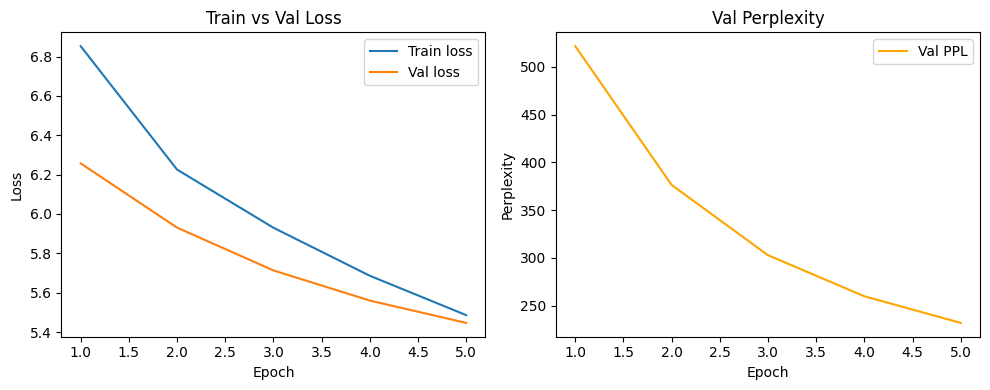

In [ ]:
plot_model_results(train_losses=lstm_train_losses, val_losses=lstm_val_losses)

* Train loss падает с каждой эпохой — модель учится на тренировочных данных
* Val PPL падает — на новых данных качество также улучшается. х2 улучшение 5-й эпохи к первой

* Модель маленькая (10M параметров), датасет небольшой
* Лучший результат был на эпохе 5 (val PPL = ~230-250)
* Нет регуляризации (dropout, weight decay). возможно стоит дальше добавить чтобюы дальше улучшить резцльтат и попробовать увеличить кол-во эпох. На 5-и пока не вино что модель переобучается

### GRU

In [ ]:
gru_model = set_model('gru')
num_params = sum(p.numel() for p in gru_model.parameters())
print(f"Параметров: {num_params:,}")

Параметров: 10,069,030


In [ ]:
gru_train_losses, gru_val_losses = train_model(model=gru_model)

Epoch 1: 100%|██████████| 105/105 [00:03<00:00, 28.32it/s]


Epoch 1 | train loss: 6.678 | val PPL: 451.6


Epoch 2: 100%|██████████| 105/105 [00:03<00:00, 30.18it/s]


Epoch 2 | train loss: 6.036 | val PPL: 306.3


Epoch 3: 100%|██████████| 105/105 [00:03<00:00, 29.42it/s]


Epoch 3 | train loss: 5.649 | val PPL: 241.3


Epoch 4: 100%|██████████| 105/105 [00:03<00:00, 33.63it/s]


Epoch 4 | train loss: 5.349 | val PPL: 212.2


Epoch 5: 100%|██████████| 105/105 [00:03<00:00, 28.27it/s]

Epoch 5 | train loss: 5.102 | val PPL: 198.5


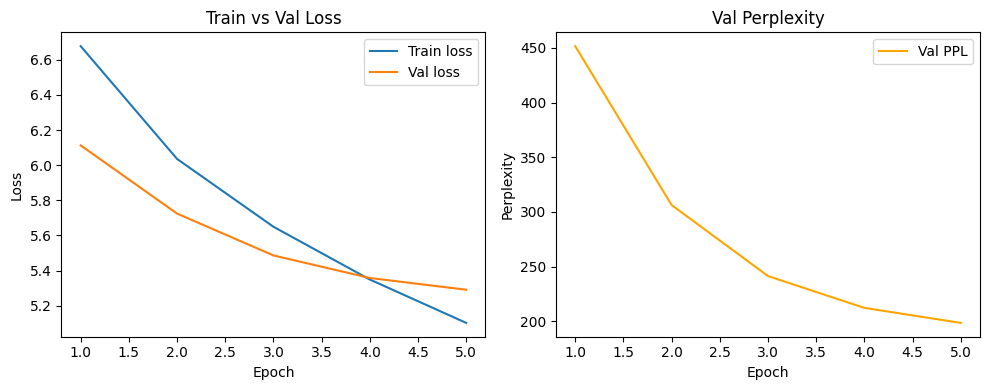

In [ ]:
plot_model_results(train_losses=gru_train_losses, val_losses=gru_val_losses)

* Train loss GRU падает с каждой эпохой — модель учится на тренировочных данных
* Val PPL растёт — на новых данных качество также улучшается. >х2 улучшение 5-й эпохи к первой
* GRU результат лучше чем LSTM. Скорее ввиду небольшого датасета. На таком датасете GRU обобщает предсказания лучше чем LSTM

* Модель маленькая (10M параметров), датасет небольшой
* Лучший результат был на эпохе 5 (val PPL = ~200)
* Нет регуляризации (dropout, weight decay). возможно стоит дальше добавить чтобюы дальше улучшить резцльтат и попробовать увеличить кол-во эпох. На 5-и пока не вино что модель переобучается

* GRU оказалась медленнее на MPS (~2:12 vs ~1:45)
* Обе модели ещё не переобучаются — val PPL продолжает падать, можно обучать дольше

GRU показала лучший результат: val perplexity 198 против 232 у LSTM при схожем количестве параметров (10.1M vs 10.3M). Это означает, что GRU в среднем сомневается между ~200 словами против ~230 у LSTM. На небольшом датасете WikiText-2 упрощённая архитектура GRU (2 гейта против 3 у LSTM) обобщает лучше, возможно из-за меньшего риска переобучения.

### distilgpt2. zero-shot evaluation предобученной модели

In [ ]:
model_name = "distilgpt2"
tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(model_name)
gpt_model = gpt_model.to(device)
gpt_model.eval()

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 5932.87it/s]


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
num_params = sum(p.numel() for p in gpt_model.parameters())
print(f"distilgpt2 параметров: {num_params:,}")


distilgpt2 параметров: 81,912,576


In [ ]:
# тестовый текст
test_text = " ".join([line for line in test_dataset if line.strip()])

# токенизация
encodings = tokenizer(test_text, return_tensors="pt")
input_ids = encodings.input_ids.to(device)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (286177 > 1024). Running this sequence through the model will result in indexing errors


In [53]:
max_length = 1024
stride = 512
total_loss = 0
num_chunks = 0

with torch.no_grad():
    for i in tqdm(range(0, input_ids.size(1) - max_length, stride)):
        chunk = input_ids[:, i : i + max_length]
        outputs = gpt_model(chunk, labels=chunk)
        total_loss += outputs.loss.item()
        num_chunks += 1

gpt_ppl = np.exp(total_loss / num_chunks)
print(f"distilgpt2 PPL: {gpt_ppl:.1f}")

100%|██████████| 557/557 [01:54<00:00,  4.87it/s]

distilgpt2 PPL: 43.4


* Несмотря на то, что модель не обучалась на Wikitext, perplexity такой модели в 5 раз лучше LSTM/GRU
* затраченное время на MPS - ~2 mins тчо сильно быстрее RNN моделей
* Выбирать точно неоюходимо distilgpt2

```
| Модель | Параметры | Val PPL | Примечание |
|--------|-----------|---------|------------|
| LSTM | 10.3M | 232 | обучена с нуля, 5 эпох |
| GRU | 10.1M | 198 | обучена с нуля, 5 эпох |
| distilgpt2 | 81.9M | 43 | предобучена, zero-shot |
```
> PPL LSTM/GRU и distilgpt2 не сравнимы напрямую: 
> LSTM/GRU используют word-level токенизатор (~10k слов),
> distilgpt2 — BPE (~50k подслов).